# NBA Salary EDA and Data Validation (2017-18 season)

## Why I chose this dataset
I chose `Yayun/nba-dataset-2` because I’m interested in the NBA and it’s a compact tabular dataset that allows clear EDA: salary distributions, team-level differences, and outliers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset


In [2]:
dataset_name = "Yayun/nba-dataset-2"

ds = load_dataset(dataset_name)
ds


DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'Player', 'Tm', 'season17_18'],
        num_rows: 573
    })
})

In [3]:
# Hugging Face dataset metadata / structure
print(ds)
print("Splits:", ds.keys())
print("Rows in train:", ds["train"].num_rows)
print("Features:", ds["train"].features)


DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'Player', 'Tm', 'season17_18'],
        num_rows: 573
    })
})
Splits: dict_keys(['train'])
Rows in train: 573
Features: {'Unnamed: 0': Value('int64'), 'Player': Value('string'), 'Tm': Value('string'), 'season17_18': Value('float64')}


In [4]:
df = ds["train"].to_pandas()

print("Shape (rows, cols):", df.shape)
df.head(10)


Shape (rows, cols): (573, 4)


,Unnamed: 0,Player,Tm,season17_18
0,1,Stephen Curry,GSW,34682550.0
1,2,LeBron James,CLE,33285709.0
2,3,Paul Millsap,DEN,31269231.0
3,4,Gordon Hayward,BOS,29727900.0
4,5,Blake Griffin,DET,29512900.0
5,6,Kyle Lowry,TOR,28703704.0
6,7,Russell Westbrook,OKC,28530608.0
7,8,Mike Conley,MEM,28530608.0
8,9,James Harden,HOU,28299399.0
9,10,DeMar DeRozan,TOR,27739975.0


In [5]:
df.info()

# Summary of all columns (including non-numeric)
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   573 non-null    int64  
 1   Player       573 non-null    object 
 2   Tm           573 non-null    object 
 3   season17_18  573 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 18.0+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,573.0,NaN,NaN,NaN,287.0,165.555127,1.0,144.0,287.0,430.0,573.0
Player,573,535,DeAndre Liggins,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tm,573,30,ATL,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season17_18,573.0,NaN,NaN,NaN,5858945.886562,7162373.478597,17224.0,1312611.0,2386864.0,7936509.0,34682550.0


In [6]:
print("Columns:", list(df.columns))

# Quick unique counts for key columns (only if they exist)
for col in ["Player", "Tm"]:
    if col in df.columns:
        print(f"{col} unique:", df[col].nunique())
        print(df[col].value_counts().head(10), "\n")


Columns: ['Unnamed: 0', 'Player', 'Tm', 'season17_18']
Player unique: 535
Player
DeAndre Liggins      3
Demetrius Jackson    3
Briante Weber        3
Jarell Eddie         3
Isaiah Canaan        3
Nigel Hayes          3
Sean Kilpatrick      3
Quinn Cook           2
Ersan Ilyasova       2
Kyle Collinsworth    2
Name: count, dtype: int64 

Tm unique: 30
Tm
ATL    27
CHI    24
DAL    22
MIL    22
HOU    22
LAL    22
PHO    21
NYK    21
NOP    21
PHI    20
Name: count, dtype: int64 



In [7]:
# Rename "Unnamed: 0" if present
if "Unnamed: 0" in df.columns:
    df = df.rename(columns={"Unnamed: 0": "row_id"})

salary_col = "season17_18"  # dataset uses this name

# Convert salary to numeric safely (handles commas, blanks)
if salary_col in df.columns:
    df[salary_col] = (
        df[salary_col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
    )
    df[salary_col] = pd.to_numeric(df[salary_col], errors="coerce")

df.head()


,row_id,Player,Tm,season17_18
0,1,Stephen Curry,GSW,34682550.0
1,2,LeBron James,CLE,33285709.0
2,3,Paul Millsap,DEN,31269231.0
3,4,Gordon Hayward,BOS,29727900.0
4,5,Blake Griffin,DET,29512900.0


## Data quality checks

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

print("Total missing cells:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

# Common checks
if "Player" in df.columns:
    print("Duplicate Player names:", int(df["Player"].duplicated().sum()))


Total missing cells: 0
Duplicate rows: 0
Duplicate Player names: 38


## Salary distribution and outliers

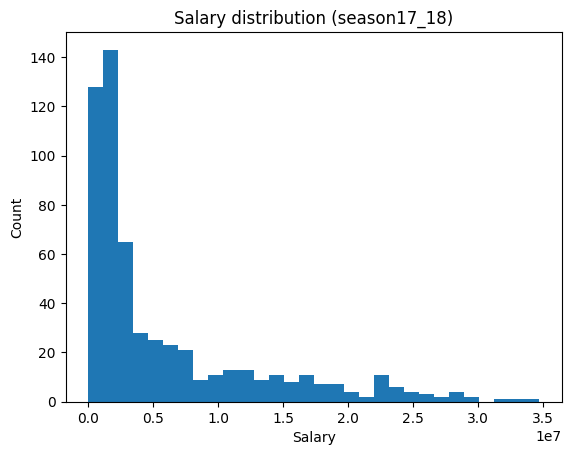

In [9]:
plt.figure()
plt.hist(df[salary_col].dropna(), bins=30)
plt.title("Salary distribution (season17_18)")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()


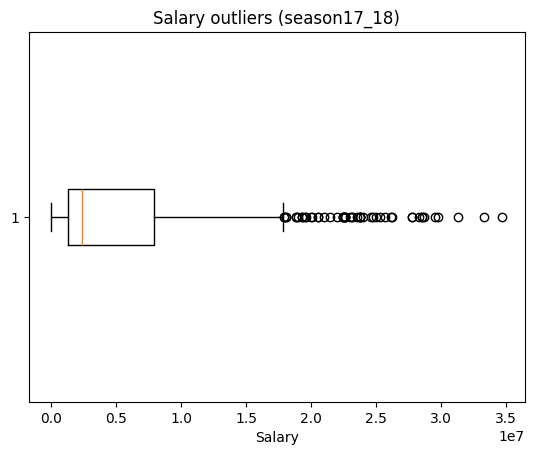

In [10]:
plt.figure()
plt.boxplot(df[salary_col].dropna(), vert=False)
plt.title("Salary outliers (season17_18)")
plt.xlabel("Salary")
plt.show()


## Highest earners and team payrolls

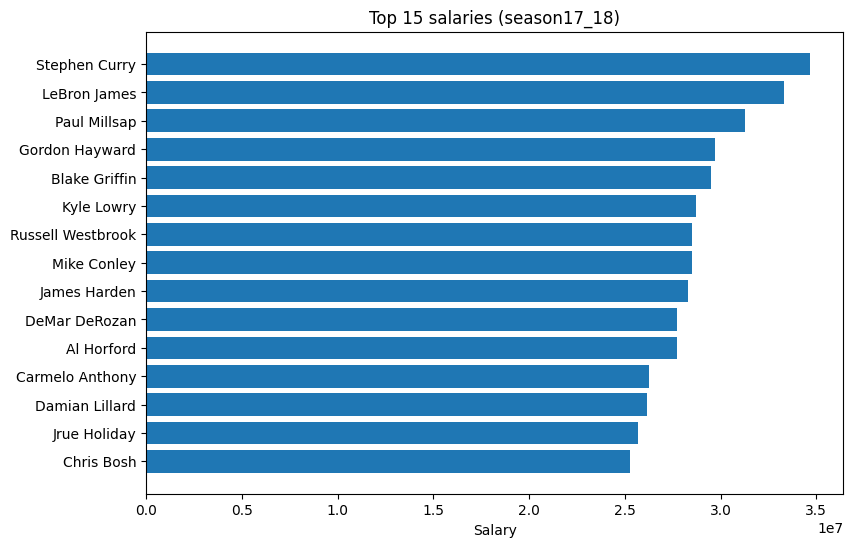

,Player,Tm,season17_18
0,Stephen Curry,GSW,34682550.0
1,LeBron James,CLE,33285709.0
2,Paul Millsap,DEN,31269231.0
3,Gordon Hayward,BOS,29727900.0
4,Blake Griffin,DET,29512900.0
5,Kyle Lowry,TOR,28703704.0
6,Russell Westbrook,OKC,28530608.0
7,Mike Conley,MEM,28530608.0
8,James Harden,HOU,28299399.0
9,DeMar DeRozan,TOR,27739975.0


In [11]:
top15 = df.dropna(subset=[salary_col]).sort_values(salary_col, ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(top15["Player"], top15[salary_col])
plt.title("Top 15 salaries (season17_18)")
plt.xlabel("Salary")
plt.gca().invert_yaxis()
plt.show()

top15[["Player", "Tm", salary_col]]


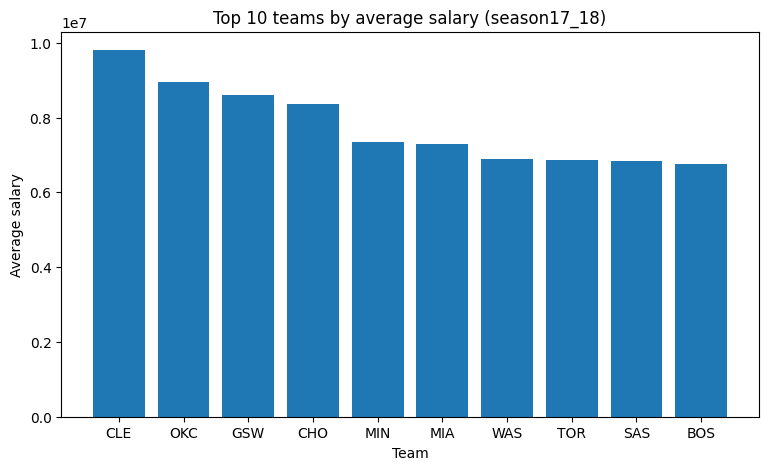

In [12]:
team_summary = (
    df.dropna(subset=[salary_col])
      .groupby("Tm")[salary_col]
      .agg(count="count", mean="mean", median="median")
      .sort_values("mean", ascending=False)
)

team_summary.head(15)


top_teams = team_summary.head(10)

plt.figure(figsize=(9, 5))
plt.bar(top_teams.index, top_teams["mean"])
plt.title("Top 10 teams by average salary (season17_18)")
plt.xlabel("Team")
plt.ylabel("Average salary")
plt.show()


## Validating the data with Great Expectations

In [13]:
import great_expectations as gx
import great_expectations.expectations as gxe

print("Great Expectations version:", gx.__version__)

context = gx.get_context()

batch = context.data_sources.pandas_default.read_dataframe(df)

batch



Great Expectations version: 1.11.2


In [14]:
salary_col = "season17_18"

expectations = []

# Existence checks
for col in ["Player", "Tm", salary_col]:
    if col in df.columns:
        expectations.append(gxe.ExpectColumnToExist(column=col))

# Not-null checks
for col in ["Player", "Tm", salary_col]:
    if col in df.columns:
        expectations.append(gxe.ExpectColumnValuesToNotBeNull(column=col))

# Team format: 3 uppercase letters (e.g., TOR, GSW)
if "Tm" in df.columns:
    expectations.append(
        gxe.ExpectColumnValuesToMatchRegex(column="Tm", regex=r"^[A-Z]{3}$")
    )

# Salary range check (sane bounds)
if salary_col in df.columns:
    expectations.append(
        gxe.ExpectColumnValuesToBeBetween(column=salary_col, min_value=0, max_value=60000000)
    )

# Optional: uniqueness of player name (may fail; that's fine to report)
if "Player" in df.columns:
    expectations.append(
        gxe.ExpectColumnValuesToBeUnique(column="Player")
    )

len(expectations)


9

In [15]:
validation_summary = []

for exp in expectations:
    result = batch.validate(expect=exp)

    validation_summary.append({
        "expectation": exp.__class__.__name__,   # ✅ works across GX versions
        "success": getattr(result, "success", None),
        "details": (
            result.describe() if hasattr(result, "describe")
            else (result.to_json_dict() if hasattr(result, "to_json_dict") else str(result))
        )
    })

# Show a quick table of pass/fail
summary_df = pd.DataFrame(validation_summary)[["expectation", "success"]]
summary_df



,expectation,success
0,ExpectColumnToExist,True
1,ExpectColumnToExist,True
2,ExpectColumnToExist,True
3,ExpectColumnValuesToNotBeNull,True
4,ExpectColumnValuesToNotBeNull,True
5,ExpectColumnValuesToNotBeNull,True
6,ExpectColumnValuesToMatchRegex,True
7,ExpectColumnValuesToBeBetween,True
8,ExpectColumnValuesToBeUnique,False


In [16]:
failed = [r for r in validation_summary if r["success"] is False]

print("Failed expectations:", len(failed))

for r in failed[:10]:
    print("\n---")
    print("Expectation:", r["expectation"])
    print("Details:", r["details"])


Failed expectations: 1

---
Expectation: ExpectColumnValuesToBeUnique
Details: {
    "expectation_type": "expect_column_values_to_be_unique",
    "success": false,
    "kwargs": {
        "batch_id": "default_pandas_datasource-#ephemeral_pandas_asset",
        "column": "Player"
    },
    "result": {
        "element_count": 573,
        "unexpected_count": 69,
        "unexpected_percent": 12.041884816753926,
        "partial_unexpected_list": [
            "Greg Monroe",
            "Dwyane Wade",
            "Jamal Crawford",
            "Joe Johnson",
            "Marco Belinelli",
            "Ersan Ilyasova",
            "Josh Smith",
            "Greg Monroe",
            "Jameer Nelson",
            "Jamal Crawford",
            "Rajon Rondo",
            "Anthony Tolliver",
            "Rajon Rondo",
            "Richard Jefferson",
            "Arron Afflalo",
            "Ramon Sessions",
            "Dwyane Wade",
            "Richard Jefferson",
            "Georgios Papa

In [17]:
gx_findings = []

for r in validation_summary:
    if r["success"] is False:
        gx_findings.append(f"- FAILED Expectation: {r['expectation']} (Player not unique)")

    elif r["success"] is True:
        pass

if not gx_findings:
    gx_findings = ["- No failed expectations (all checks passed)."]

gx_findings


['- FAILED Expectation: ExpectColumnValuesToBeUnique (Player not unique)']

## Exporting a one-page PDF summary

In [18]:
from fpdf import FPDF
from fpdf.enums import XPos, YPos

def ascii_safe(s: str) -> str:
    return (
        str(s)
        .replace("\u2014", "-")
        .replace("\u2013", "-")
        .replace("’", "'")
        .replace("“", '"')
        .replace("”", '"')
        .replace("•", "-")
    )

# --- helpers that ALWAYS reset X to left margin before printing ---
def h(pdf, text, size=12):
    pdf.set_x(pdf.l_margin)
    pdf.set_font("Helvetica", "B", size)
    pdf.cell(0, 7, ascii_safe(text), new_x=XPos.LMARGIN, new_y=YPos.NEXT)

def p(pdf, text):
    pdf.set_x(pdf.l_margin)
    pdf.set_font("Helvetica", "", 11)
    pdf.multi_cell(0, 6, ascii_safe(text))

# ---- compute stats ----
rows, cols = df.shape
num_players = df["Player"].nunique() if "Player" in df.columns else None
num_teams = df["Tm"].nunique() if "Tm" in df.columns else None

total_missing = int(df.isna().sum().sum())
dup_rows = int(df.duplicated().sum())

salary_col = "season17_18"
salary_stats = {}
if salary_col in df.columns:
    s = df[salary_col].dropna()
    if len(s) > 0:
        salary_stats = {
            "min": float(s.min()),
            "median": float(s.median()),
            "mean": float(s.mean()),
            "max": float(s.max()),
        }

failed_lines = gx_findings[:4] if "gx_findings" in globals() else ["- GX findings not generated."]

insights = []
if salary_stats.get("max") is not None and salary_stats.get("median") is not None:
    insights.append("- Salary is right-skewed: a small number of players earn far above the median.")
insights.append("- Boxplot/top-15 plot highlight extreme salary outliers.")
if num_teams is not None:
    insights.append("- Team-level salary averages vary across teams (aggregation could be useful).")
if total_missing > 0:
    insights.append("- Missing values exist and should be handled before modeling.")

overview_lines = [
    f"- Rows: {rows} | Columns: {cols}",
    f"- Sampling: not needed (dataset is small: {rows} rows).",
    f"- Columns (types): row_id (int), Player (str), Tm (str), {salary_col} (float).",
    f"- Missing cells (total): {total_missing} | Duplicate rows: {dup_rows}",
]
if num_players is not None:
    overview_lines.append(f"- Unique players: {num_players}")
if num_teams is not None:
    overview_lines.append(f"- Unique teams: {num_teams}")
if salary_stats.get("mean") is not None:
    overview_lines.append(
        f"- Salary stats ({salary_col}): min={salary_stats['min']:.0f}, "
        f"median={salary_stats['median']:.0f}, mean={salary_stats['mean']:.0f}, "
        f"max={salary_stats['max']:.0f}"
    )

# ---- build PDF ----
pdf = FPDF()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=10)

pdf.set_x(pdf.l_margin)
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 8, ascii_safe("EDA Report - Yayun/nba-dataset-2"), new_x=XPos.LMARGIN, new_y=YPos.NEXT)

p(pdf, "Exploratory data analysis and data validation of 2017-18 NBA salaries")

h(pdf, "Why this dataset", size=12)
p(pdf,
  "I chose this NBA dataset because it's small enough to analyze quickly, but still contains meaningful real-world patterns "
  "(salary skew, outliers, and team differences) that are useful for EDA and future modeling."
)

h(pdf, "Dataset overview", size=12)
p(pdf, "\n".join(overview_lines))

h(pdf, "Key EDA findings", size=12)
p(pdf, "\n".join(insights[:6]))

h(pdf, "Data quality checks (Great Expectations)", size=12)
p(pdf, "\n".join(failed_lines))

h(pdf, "Why this matters for future modeling", size=12)
p(pdf,
  "- Skewed salary distributions often benefit from transformations.\n"
  "- Team-level aggregates may become useful engineered features.\n"
  "- Data quality issues must be fixed before future modeling/training."
)

out_path = "nba_eda_report.pdf"
pdf.output(out_path)
out_path



'nba_eda_report.pdf'